Hola buenos días

¡Gráfica generada con ajuste ponderado y errores de parámetros!


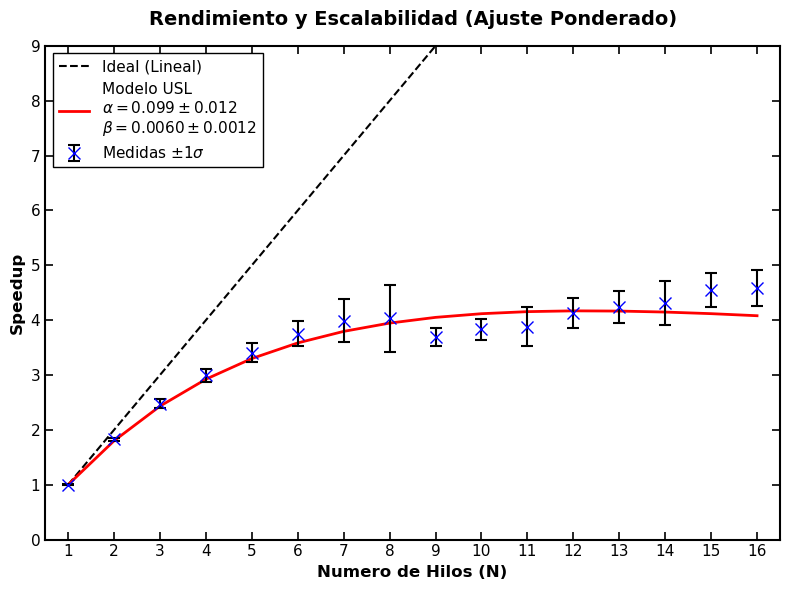

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def funcion_usl(n, alpha, beta):
    return n / (1 + alpha * (n - 1) + beta * n * (n - 1))

def main():
    try:
        df = pd.read_csv('amdahl_estadistico.csv')
    except FileNotFoundError:
        print("Error: No se encontró 'amdahl_estadistico.csv'.")
        return

    hilos = df['Hilos'].values
    t_medios = df['Tiempo_Medio_ms'].values
    t_std = df['Desviacion_ms'].values

    T1_medio = t_medios[0]
    T1_std = t_std[0]

    # Cálculos estadísticos y de Speedup
    speedup_medio = T1_medio / t_medios
    speedup_err = speedup_medio * np.sqrt((T1_std / T1_medio)**2 + (t_std / t_medios)**2)

    # ====================================================================
    # MAGIA ESTADÍSTICA: Ajuste Ponderado (Chi-cuadrado)
    # sigma=speedup_err: Los puntos con menos error pesan más en el ajuste
    # absolute_sigma=True: Los errores están en las mismas unidades que Y
    # ====================================================================
    popt, pcov = curve_fit(funcion_usl, hilos, speedup_medio, 
                           sigma=speedup_err, absolute_sigma=True, 
                           bounds=(0.0, 1.0))
    
    alpha_est, beta_est = popt
    
    # Extraemos los errores de los parámetros desde la matriz de covarianza
    errores_parametros = np.sqrt(np.diag(pcov))
    alpha_err, beta_err = errores_parametros

    speedup_ideal = hilos  
    speedup_usl = funcion_usl(hilos, alpha_est, beta_est)

    # ==========================================
    # ESTILO GNUPLOT MEJORADO (Fondo blanco, caja negra)
    # ==========================================
    plt.style.use('default') # Base limpia
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Configuración de los bordes (Spines) negros y gruesos
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    # Ticks hacia adentro y en todos los bordes (Puro Gnuplot)
    ax.tick_params(direction='in', top=True, right=True, length=6, width=1.2, labelsize=11)

    # Dibujamos las curvas
    ax.plot(hilos, speedup_ideal, 'k--', linewidth=1.5, label='Ideal (Lineal)')
    
    # Ahora la leyenda incluye el valor ± su error
    etiqueta_usl = f'Modelo USL\n$\\alpha = {alpha_est:.3f} \\pm {alpha_err:.3f}$\n$\\beta = {beta_est:.4f} \\pm {beta_err:.4f}$'
    ax.plot(hilos, speedup_usl, 'r-', linewidth=2, label=etiqueta_usl)
    
    # Datos con barras de error
    ax.errorbar(hilos, speedup_medio, yerr=speedup_err, fmt='bx', 
                markersize=8, capsize=4, capthick=1.5, elinewidth=1.5, 
                ecolor='black', label='Medidas $\\pm 1\\sigma$')

    # Textos
    ax.set_xlabel('Numero de Hilos (N)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Speedup', fontsize=12, fontweight='bold')
    ax.set_title('Rendimiento y Escalabilidad (Ajuste Ponderado)', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticks(hilos)
    ax.set_xlim(0.5, max(hilos) + 0.5)
    ax.set_ylim(0, max(speedup_ideal)/2 + 1)
    
    # Leyenda estilo caja cerrada clásica
    ax.legend(loc='upper left', frameon=True, edgecolor='black', 
              fancybox=False, framealpha=1.0, fontsize=11)
    
    plt.tight_layout()
    plt.savefig('grafica_usl_gnuplot_corregida.png', dpi=300)
    print("¡Gráfica generada con ajuste ponderado y errores de parámetros!")
    plt.show()

if __name__ == '__main__':
    main()